In [1]:
import sys

sys.path.append("/Users/krisztianivankai/PycharmProjects/Szakdolgozat/")

from models.fuzzy import *
from models.moving_average import forecast_moving_average
from utilities.utils import *
from evaluate.evaluate_model import get_model_score
from forecast.forecast import forecast_over_horizon

In [2]:
sales_and_stock = pd.read_csv('Szakdoga_adat.csv')
split_percentage = 0.8
lags_to_use = 7

In [3]:
holidays_df = get_holidays_df()

In [4]:
get_date_features(sales_and_stock)

,date,sales,stock,day_of_week,month,quarter,year,year_quarter
0,2024-01-01,NaN,32,0,1,1,2024,2024Q1
1,2024-01-02,10.0,22,1,1,1,2024,2024Q1
2,2024-01-03,13.0,9,2,1,1,2024,2024Q1
3,2024-01-04,25.0,34,3,1,1,2024,2024Q1
4,2024-01-05,27.0,7,4,1,1,2024,2024Q1
...,...,...,...,...,...,...,...,...
784,2026-02-23,76.0,335,0,2,1,2026,2026Q1
785,2026-02-24,74.0,261,1,2,1,2026,2026Q1
786,2026-02-25,66.0,195,2,2,1,2026,2026Q1
787,2026-02-26,55.0,140,3,2,1,2026,2026Q1


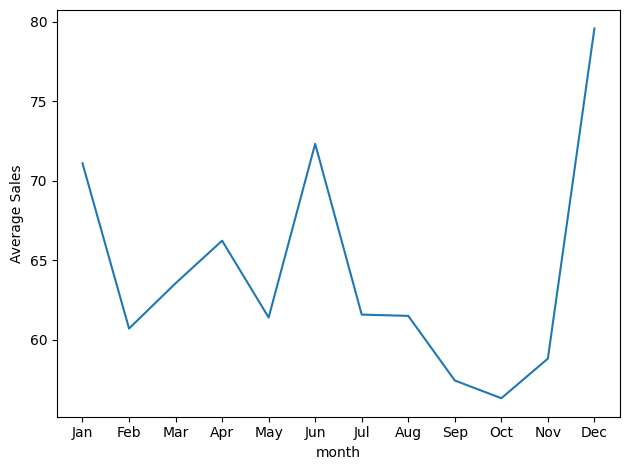

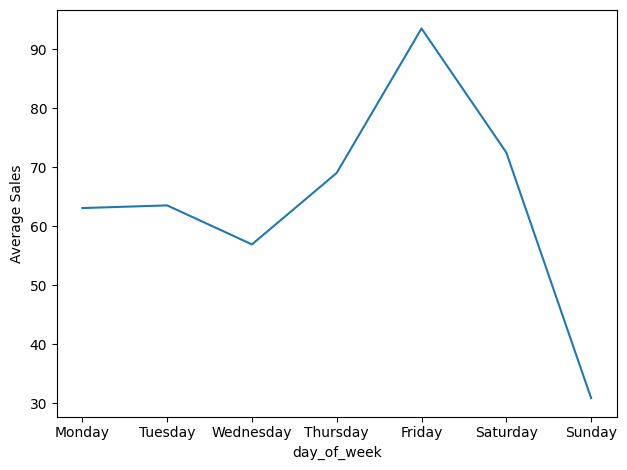

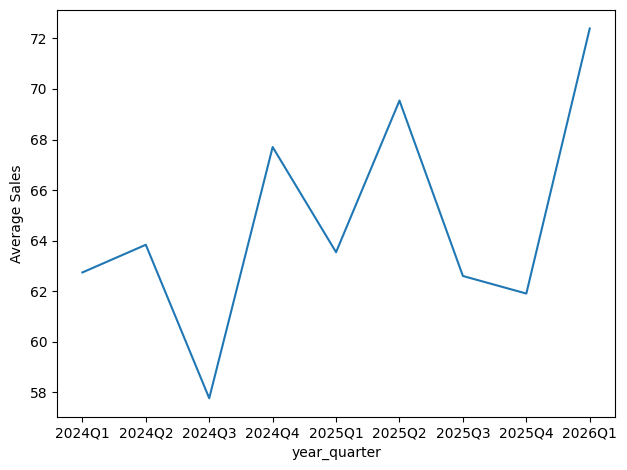

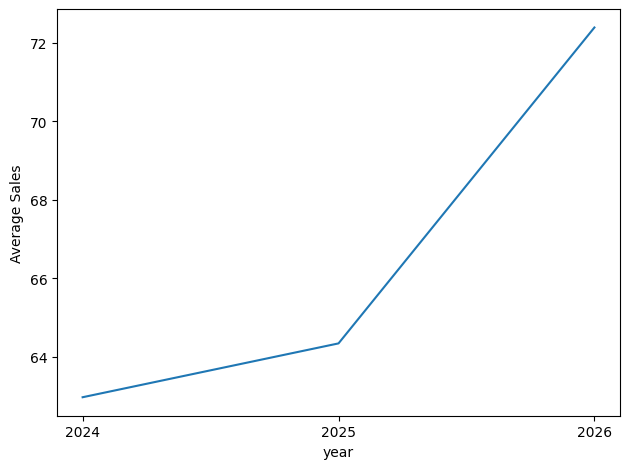

In [5]:
plot_average_by_group(sales_and_stock, 'month')
plot_average_by_group(sales_and_stock, 'day_of_week')
plot_average_by_group(sales_and_stock, 'year_quarter', 45)
plot_average_by_group(sales_and_stock, 'year')

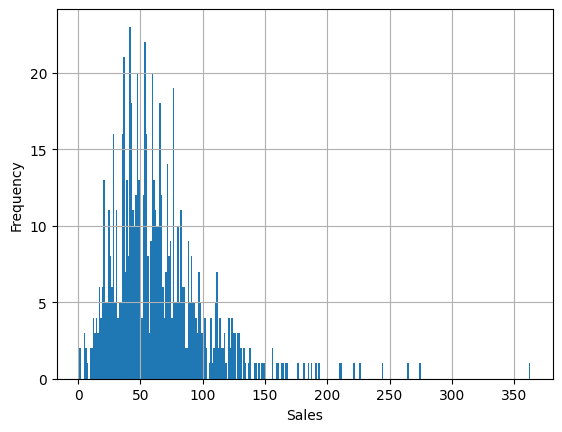

In [6]:
sales_and_stock["sales"].hist(bins=300)#,figsize=(10,10))
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

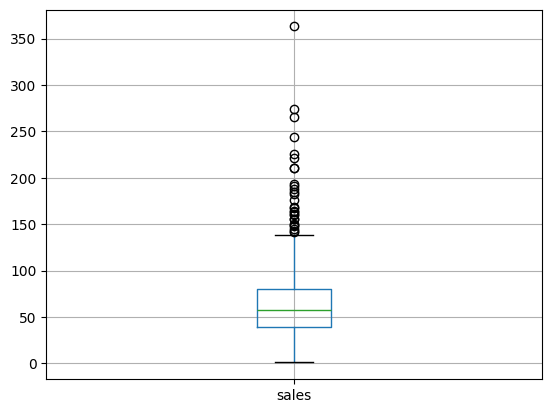

In [7]:
sales_and_stock.boxplot(column="sales")
plt.show()

In [8]:
calculate_adi(sales_and_stock)

np.float64(1.0)

In [9]:
calculate_cv(sales_and_stock)

np.float64(0.5981896621713417)

In [10]:
demand = get_prepared_demand_df(sales_and_stock).merge(holidays_df, how='left_anti', left_on='date', right_on='date').drop(columns=['holiday'])

In [11]:
demand[['demand']].describe()

,demand
count,762.000000
mean,64.130577
std,38.087063
min,0.000000
25%,40.000000
50%,58.000000
75%,80.000000
max,363.000000


In [12]:
calculate_adi(demand,'demand')

np.float64(1.0026315789473683)

In [13]:
calculate_cv(demand,'demand')

np.float64(0.5938986450650299)

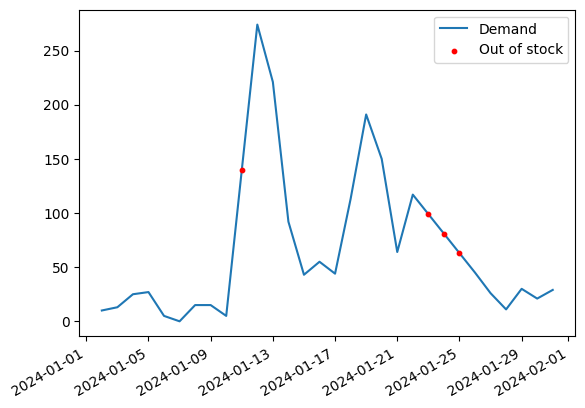

In [14]:
plot_imputed_values_with_missing_stock(demand.head(30))

In [15]:
split_date = get_split_date(sales_and_stock['date'], split_percentage)
train_data = demand[demand['date'] < split_date].reset_index(drop=True)
test_data = demand[demand['date'] >= (split_date - timedelta(days=lags_to_use))].reset_index(drop=True)[['date','demand']]

In [16]:
statistics = train_data[['demand']].describe()

In [17]:
demand_min = 0 #statistics.T["min"].to_list()[0]
demand_first_quartile = 25#statistics.T["25%"].to_list()[0]
demand_median = 50#statistics.T["50%"].to_list()[0]
demand_third_quartile = 100#statistics.T["75%"].to_list()[0]
demand_max = 500#statistics.T["max"].to_list()[0]

In [18]:
fuzzy_sets = [
    {
        "name": "VeryLowDemand",
        "type": "shoulder",
        "a": demand_min,
        "b": demand_first_quartile,
        "direction": "left",
    },
    {
        "name": "LowDemand",
        "type": "triangular",
        "a": demand_min,
        "b": demand_first_quartile,
        "c": demand_median,
    },
    {
        "name": "MediumDemand",
        "type": "triangular",
        "a": demand_first_quartile,
        "b": demand_median,
        "c": demand_third_quartile,
    },
    {
        "name": "HighDemand",
        "type": "triangular",
        "a": demand_median,
        "b": demand_third_quartile,
        "c": demand_max
    },
    {
        "name": "VeryHighDemand",
        "type": "shoulder",
        "a": demand_third_quartile,
        "b": demand_max,
        "direction": "right"
    }
]

In [19]:
rule_base = create_rule_base_df(train_data, lags_to_use, fuzzy_sets)

In [20]:
rule_base

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set,demand
0,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,42.0
1,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,MediumDemand,69.0
2,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,HighDemand,82.0
3,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,MediumDemand,HighDemand,125.0
4,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,HighDemand,HighDemand,94.5
...,...,...,...,...,...,...,...,...
413,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,HighDemand,HighDemand,43.0
414,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,LowDemand,LowDemand,16.0
415,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,25.0
416,VeryLowDemand,MediumDemand,HighDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,45.0


In [21]:
fuzz_cols = [f'lag_{i}_fuzzy_set' for i in range(1, lags_to_use+1)]

fuzzy_statistics = []

for fuzz_col in fuzz_cols:
    fuzzy_statistics.append(rule_base.groupby([fuzz_col])[[fuzz_col]].count())

pd.concat(fuzzy_statistics,axis=1)

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set
HighDemand,138,133,127,126,126,126,134
LowDemand,88,92,91,96,103,101,98
MediumDemand,181,181,187,184,177,179,173
VeryHighDemand,1,1,1,1,1,1,1
VeryLowDemand,10,11,12,11,11,11,12


In [22]:
lingustic_rules = get_linguistic_form(rule_base)

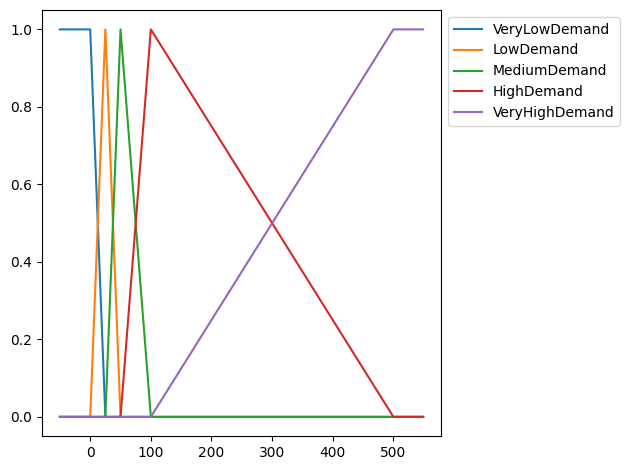

In [23]:
plot_fuzzy_sets_memberships(fuzzy_sets,demand_min,demand_max)

In [24]:
test_data = test_data.merge(holidays_df, how='left_anti', left_on='date', right_on='date').drop(columns=['holiday'])

In [25]:
validation_start_date = test_data['date'].min() + timedelta(days=lags_to_use)
forecast_horizon = (test_data['date'].max() - validation_start_date).days + 1
moving_average_forecast = forecast_over_horizon(test_data,validation_start_date,forecast_horizon,lags_to_use,forecast_moving_average,[lags_to_use])

In [26]:
log_stream = log_not_fired_rules()

In [27]:
fuzzy_model_forecast = forecast_over_horizon(test_data, validation_start_date, forecast_horizon,lags_to_use, fuzzy_forecast_pipeline, [fuzzy_sets, rule_base])

TypeError: can only concatenate list (not "str") to list

In [ ]:
log_output = log_stream.getvalue()
count = log_output.count("Rule not fired!")
print(f"Rule not fired: {count} times, that is {round(count/fuzzy_model_forecast.count().max()*100,2)}% of days")
print(f"It worked in {fuzzy_model_forecast.count().max()-count} times, which is {100-round(count/fuzzy_model_forecast.count().max()*100,2)}% of days")

In [ ]:
test_data = test_data[test_data['date']>= validation_start_date]

In [ ]:
fig, ax = plt.subplots(figsize=(50, 25))  # ✅ returns (fig, ax)

ax.plot(test_data["date"], test_data["demand"],
        label="Actual", color="steelblue", linewidth=2)
ax.plot(fuzzy_model_forecast["date"], fuzzy_model_forecast["prediction"],
        label="Fuzzy prediction", color="tomato", linewidth=2, linestyle="--")
ax.plot(moving_average_forecast["date"], moving_average_forecast["prediction"],
        label="Moving average prediction", color="green", linewidth=2, linestyle=":")

ax.set_title("Actual demand vs Fuzzy prediction vs Moving average prediction", fontsize=30)
ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Demand", fontsize=30)
ax.tick_params(axis="both", labelsize=30)
plt.xticks(rotation=45)
ax.legend(fontsize=30)
ax.grid(True, alpha=0.3)

ax.margins(x=0)
ax.set_ylim(0, 200)
ax.set_xlim(test_data["date"].min(), test_data["date"].max())

plt.tight_layout()
plt.show()

In [ ]:
fuzzy_score = get_model_score(test_data, fuzzy_model_forecast)
moving_average_score = get_model_score(test_data, moving_average_forecast)

In [ ]:
fuzzy_score

In [ ]:
moving_average_score